|컬럼명| 정의 | 타입 | 비고 |
|---|---|---|---|
| | | |

# **Wholesales customers 비지도분석 파이프라인**

## #0. 라이브러리 불러오기

In [1]:
from helper import *
import pandas as pd
import numpy as np
from IPython.display import Markdown, display

## #1. 데이터 품질 점검 및 데이터 전처리

### **1)** 데이터 구조 점검 <br>
#### **1-1** 데이터 불러오기 & 크기확인

In [2]:
# 데이터 불러오기
origin = pd.read_csv(r'./Wholesale customers data.csv', encoding='utf-8')
display(origin.head())

# 데이터 크기 확인
print('데이터 크기 : ', origin.shape)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


데이터 크기 :  (440, 8)


#### **1-2** 데이터타입 점검

In [3]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


#### **1-3** 데이터 타입 변환
- `Channel`, `Region` 컬럼은 명목형으로 변환
- 채널 및 컬럼은 연속형으로 되어있으나, 실질적으로는 명목형 변수
- `Channel` = 1.**Horeca** /  2.**Retail**
- `Region` = 1.**Lisbon** / 2.**Oporto** / 3.**Other Region**

In [4]:
df = my_qtcheck.set_type(origin, as_category=['Channel', 'Region'])

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Channel           440 non-null    category
 1   Region            440 non-null    category
 2   Fresh             440 non-null    int64   
 3   Milk              440 non-null    int64   
 4   Grocery           440 non-null    int64   
 5   Frozen            440 non-null    int64   
 6   Detergents_Paper  440 non-null    int64   
 7   Delicassen        440 non-null    int64   
dtypes: category(2), int64(6)
memory usage: 21.7 KB


#### **1-4** 데이터 중복 확인
- 중복된 행의 수는 0건

In [5]:
my_qtcheck.check_duplicates(df)

중복된 행의 수: 0


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


#### 1-5 형식, 표기, 단위, 점검 (1) - 연속형 변수

In [6]:
# 연속형 변수 목록 리스트 정의
num_cols = my_qtcheck.get_number_column_names(df)

minmax = []     # 최소값, 최대값을 저장할 리스트

for i in num_cols:          # 연속형 변수 반복문
    min_value= df[i].min()  # 최소값
    max_value = df[i].max() # 최대값
    # 반복문에 대한 최소값, 최대값 리스트 추가
    minmax.append({'min' : min_value, 'max' : max_value})   

# 최소값과 최대값을 데이터프레임으로 출력
minmax_df = pd.DataFrame(minmax, index=num_cols)
minmax_df

,min,max
Fresh,3,112151
Milk,55,73498
Grocery,3,92780
Frozen,25,60869
Detergents_Paper,3,40827
Delicassen,3,47943


#### 1-6 형식, 표기, 단위, 점검 (2) - 명목형 변수

In [7]:
# 명목형 변수 컬럼 리스트 목록
cat_cols = my_qtcheck.get_categorical_column_names(df)

# 명목형 변수에 대한 반복문
for c in cat_cols:
    count = df[c].value_counts()    # 명목형 컬럼 카운트
    display(count)                  # 카운트 출력결과


Channel
1    298
2    142
Name: count, dtype: int64

Region
3    316
1     77
2     47
Name: count, dtype: int64

### **2)** 데이터 품질 점검

#### **2-1** 데이터 결측치 확인
- 데이터 결측치 0건

In [8]:
my_qtcheck.check_missing_values(df)

,Missing Count,Missing Ratio (%)
Channel,0,0.0
Region,0,0.0
Fresh,0,0.0
Milk,0,0.0
Grocery,0,0.0
Frozen,0,0.0
Detergents_Paper,0,0.0
Delicassen,0,0.0


#### 2-2 품질 점검 데이터셋 저장

In [9]:
df.to_excel('Wholesale customers_qtcheck.xlsx', index=False)

### 3) 기술 통계량
#### 3-1 연속형 변수의 기술 통계량

In [10]:
num_desc = my_qtcheck.numerical_summary(df,
                                               save_path='Wholesale customers_numerical_summary.xlsx')
num_desc.T

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3127.75,1533.0,2153.0,742.25,256.75,408.25
50%,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,16933.75,7190.25,10655.75,3554.25,3922.0,1820.25
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0
rel_diff,0.411136,0.598088,0.672017,1.013061,2.529079,0.579358
rdiff_flag,diff,large_diff,large_diff,large_diff,large_diff,large_diff


#### 3-2 범주형 변수의 기술 통계량

In [11]:
cat_desc = my_qtcheck.categorical_summary(df)
cat_desc

📊 컬럼 'Channel'의 value_counts():


,count
Channel,
1,298
2,142


📊 컬럼 'Region'의 value_counts():


,count
Region,
1,77
2,47
3,316


,Channel,Region
count,440,440
unique,2,3
top,1,3
freq,298,316


#### 3-3 불필요한 컬럼 삭제 후, 저장

> `Region` (지역 -Lisbon:1, Oporto:2, Other:3) 고객 분포는 **Other 316명(약 71.8%)**, **Lisbon 77명(약 17.5%)**, **Oporto 47명(약 10.7%)** 순으로 **Other**로 크게 쏠려있어 집단비교가 어려워 분석대상에서 제거합니다.

In [12]:
df = df.drop(columns='Region')

# 최종 명목형 변수 기술통계량 저장
cat_desc = my_qtcheck.categorical_summary(df, 
                               save_path='Wholesale customers_categorical_summary.xlsx')

cat_desc

📊 컬럼 'Channel'의 value_counts():


,count
Channel,
1,298
2,142


,Channel
count,440
unique,2
top,1
freq,298


#### 📋 해석
 - 데이터 중심수준
 - 데이터 퍼짐과 안정성 
 - 이상치 확인
 - `Region` 데이터 불균형으로 분석에서 제외
> 작성 필요

## #2. 탐색적 데이터분석 (EDA)

### 1) 준비작업
#### 1-1 변수 유형 분류

In [19]:
target = 'Channel'
target_is_continuous = False

if target_is_continuous:
    num_cols.remove(target)

exclude_cols = 'Region'

print('종속 변수 : ', target)
print('종속 변수 유형 : ' + ('연속형' if target_is_continuous else '범주형'))
print('연속형 : ', num_cols)
print('제외된 변수 : ', exclude_cols)

종속 변수 :  Channel
종속 변수 유형 : 범주형
연속형 :  ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
제외된 변수 :  Region


#### 1-2 컬럼 의미를 정리한 딕셔너리

In [14]:
column_means = {
    'Channel' : '고객 채널',
    'Region' : '고객 지역',
    'Fresh' : '신선 식품에 대한 연간 지출액',
    'Milk' : '유제품에 대한 연간 지출액', 
    'Grocery' : '식료품에 대한 연간 지출액', 
    'Frozen' : '냉동 식품에 대한 연간 지출액',
    'Detergents_Paper' : '세제 및 종이 제품에 대한 연간 지출액', 
    'Delicassen' : '조리 식품에 대한 연간 지출액'
}

#### 1-3 EDA 범위 정리 - ppt

### 2) 단변량 분석
#### 2-1 명목형 종속변수에 대한 단변량 분석 

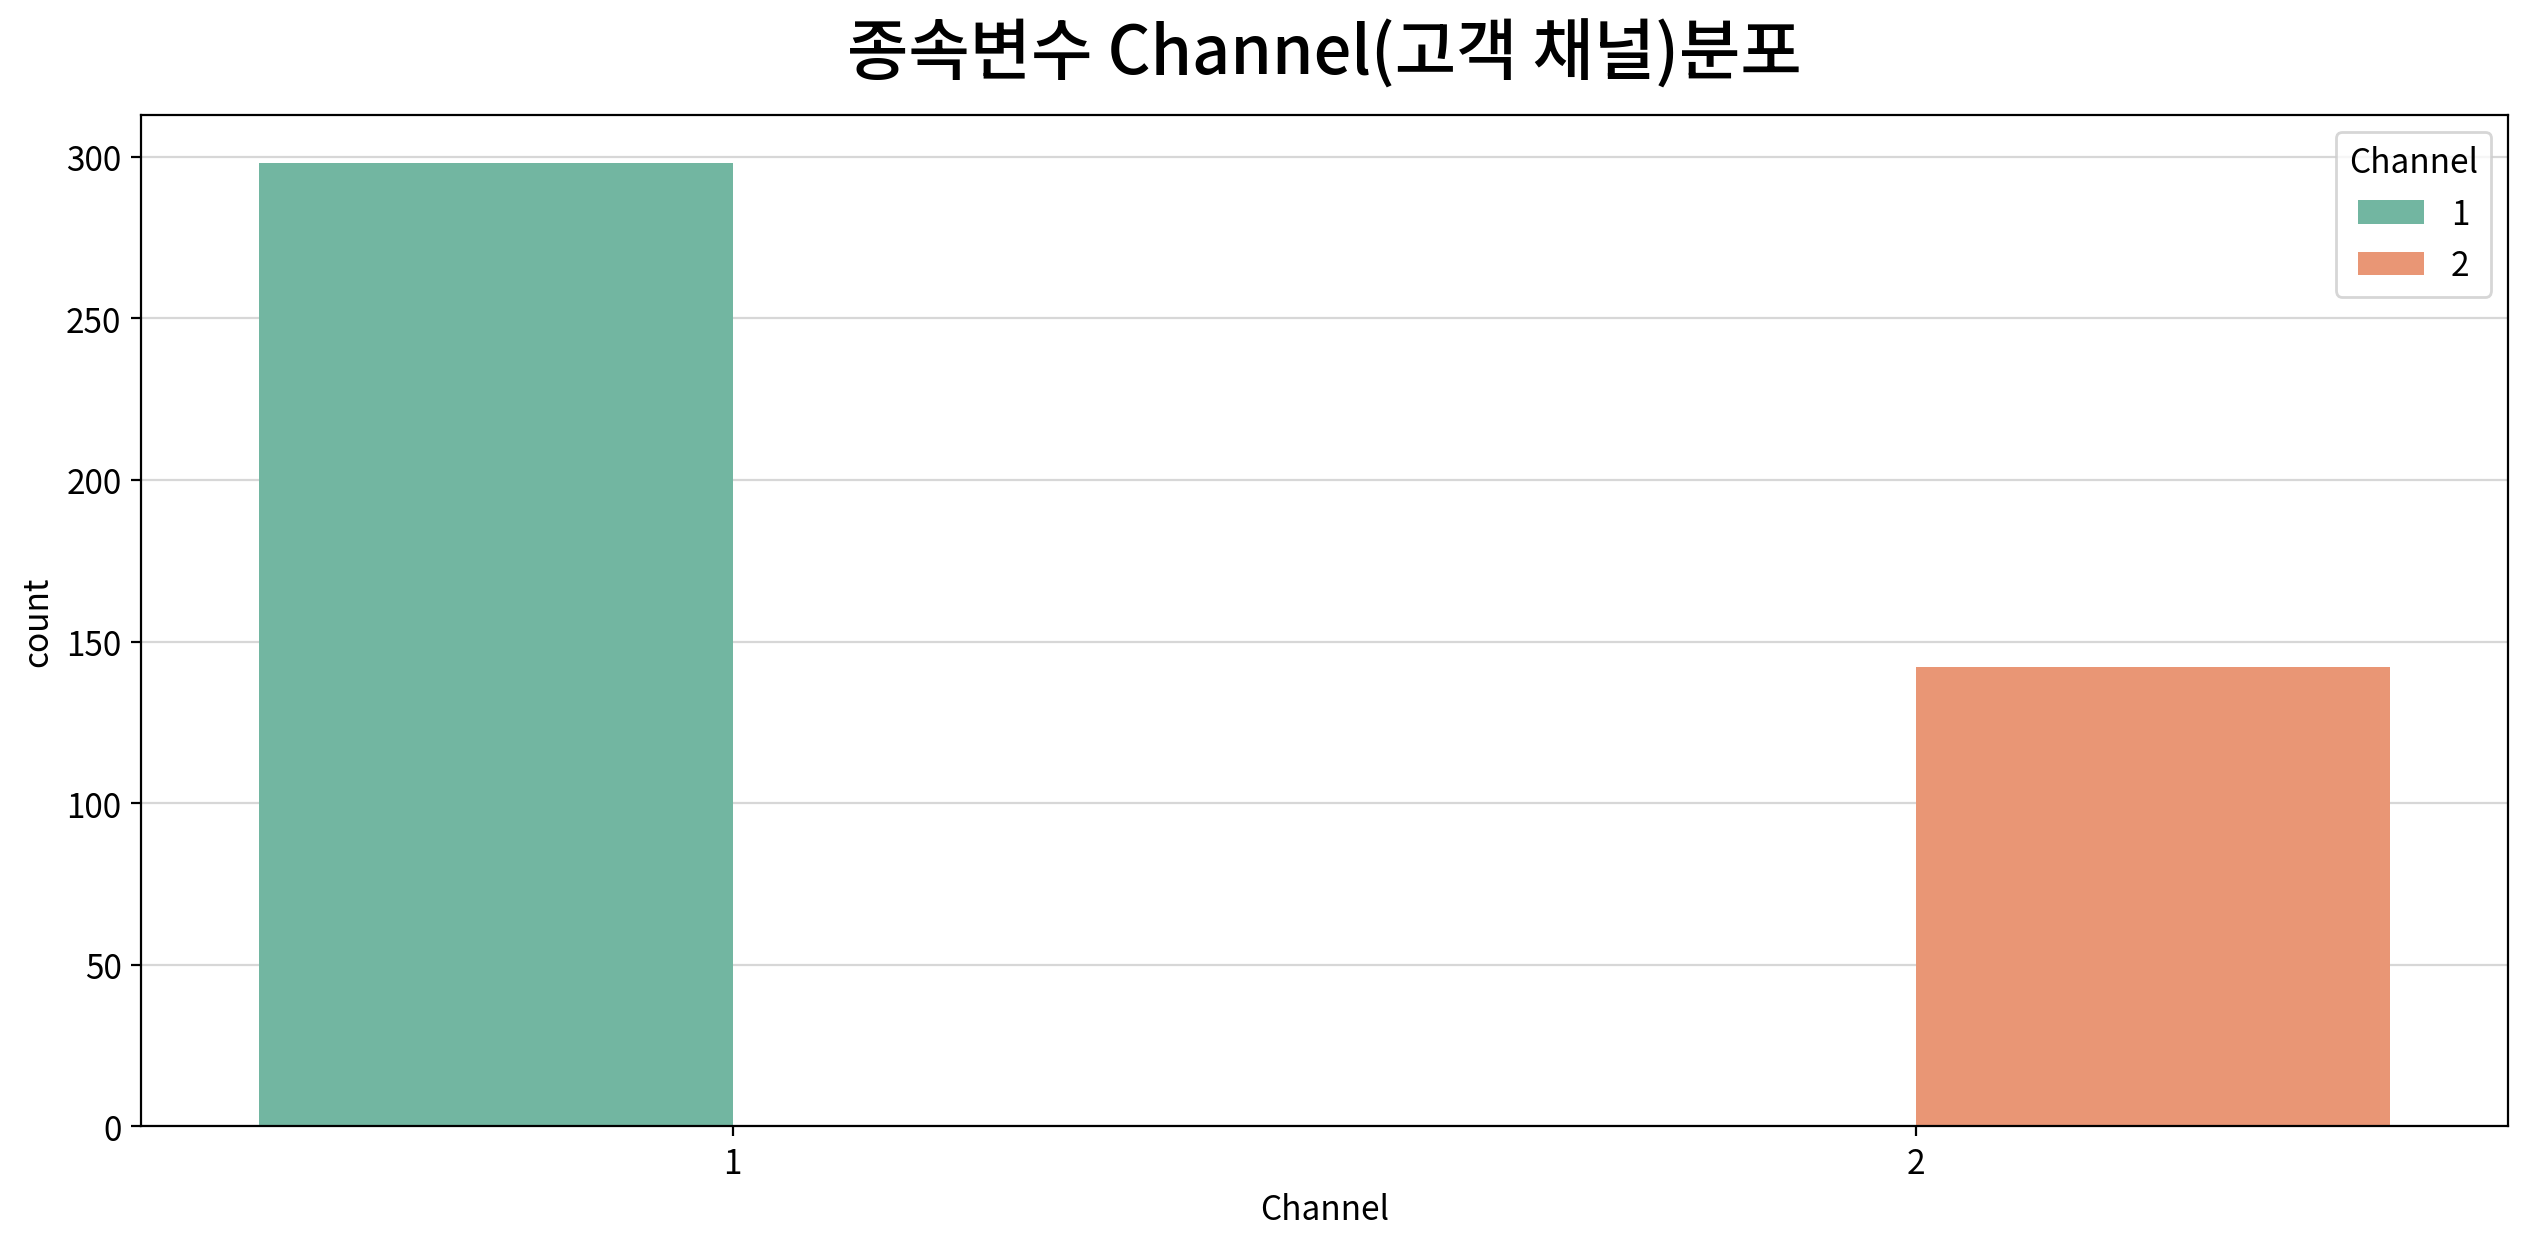

,count,unique,top,freq
Channel,440,2,1,298


,빈도,비율
Channel,,
1,298,0.677273
2,142,0.322727


In [15]:
my_plot.countplot(data=df, x=target, hue=df[target], palette='Set2',
                  title = f'종속변수 {target}({column_means[target]})분포')

display(cat_desc[[target]].T)

# 빈도표 생성
freq = df[target].value_counts().rename('빈도').to_frame()
freq['비율'] = df[target].value_counts(normalize=True)
display(freq)

#### 2-2 연속형 독립변수에 대한 단변량 분석 

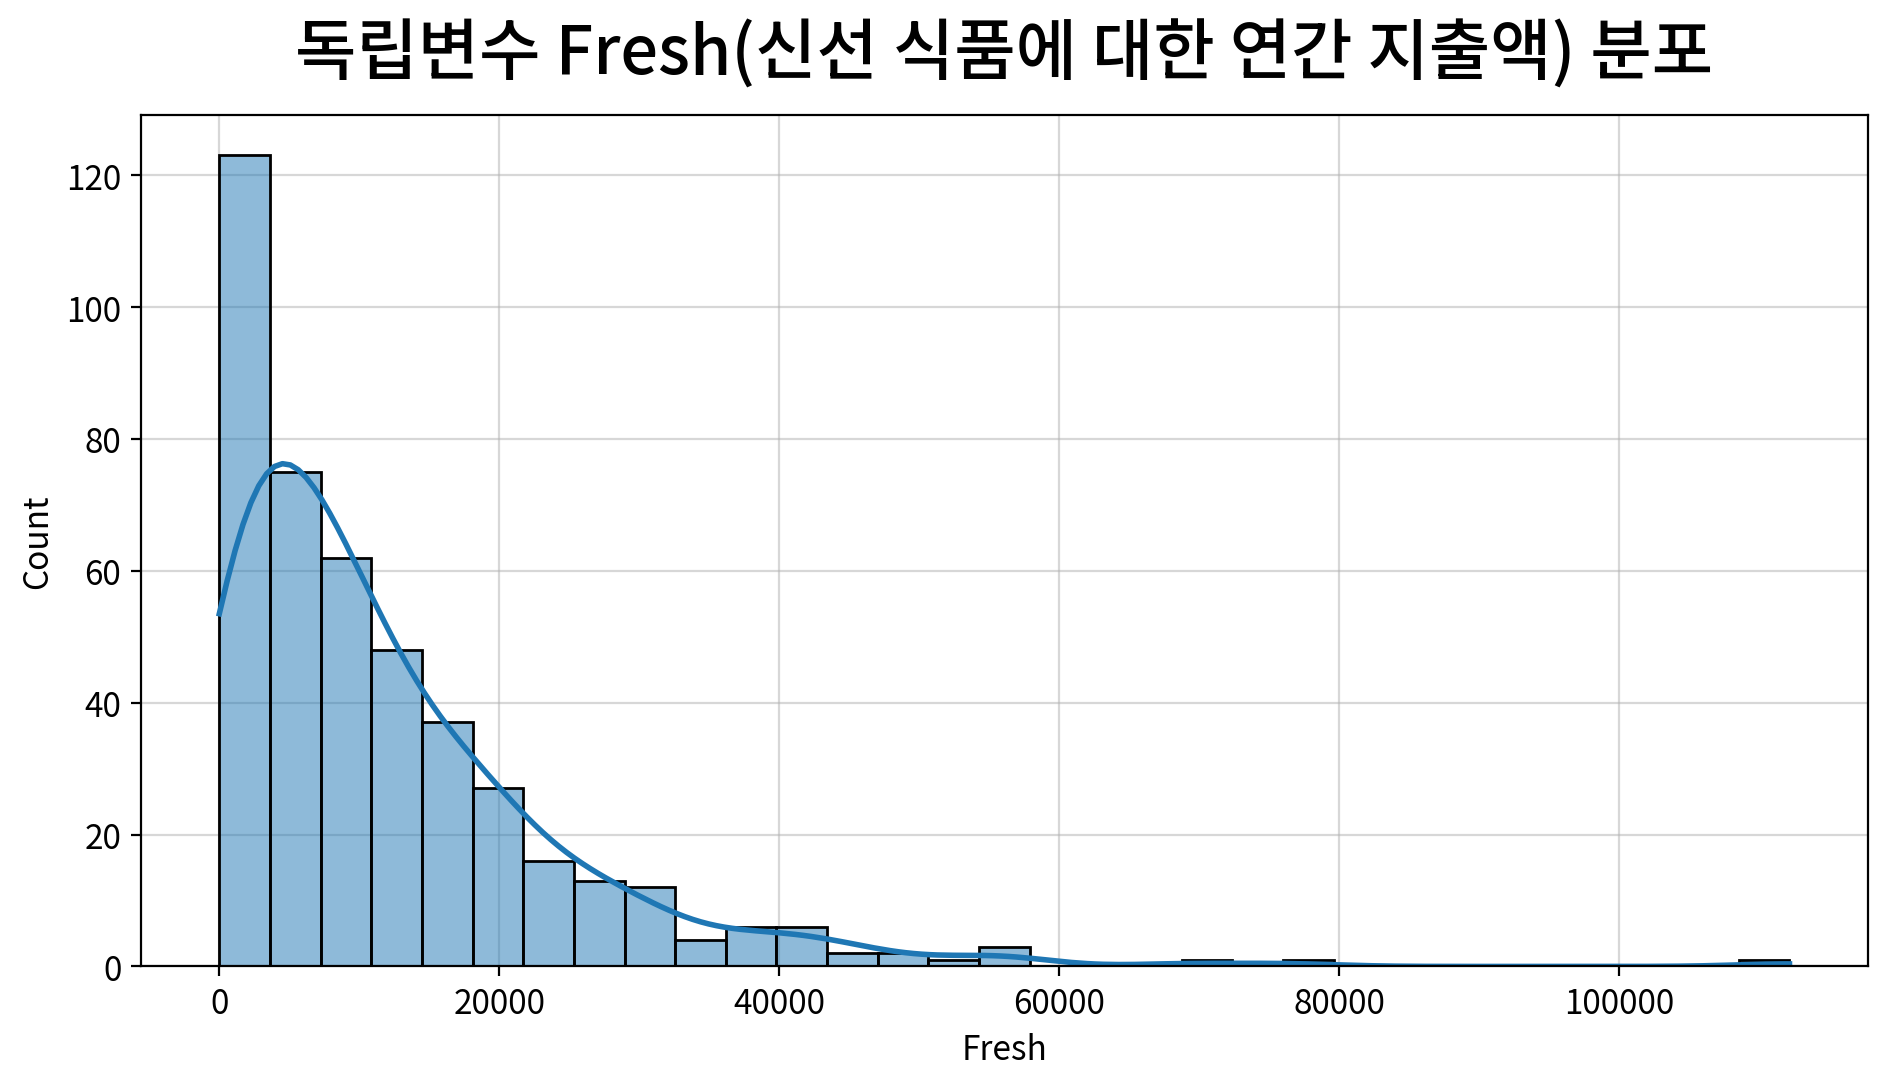

,Fresh
count,440.0
mean,12000.297727
std,12647.328865
min,3.0
25%,3127.75
50%,8504.0
75%,16933.75
max,112151.0
rel_diff,0.411136
rdiff_flag,diff


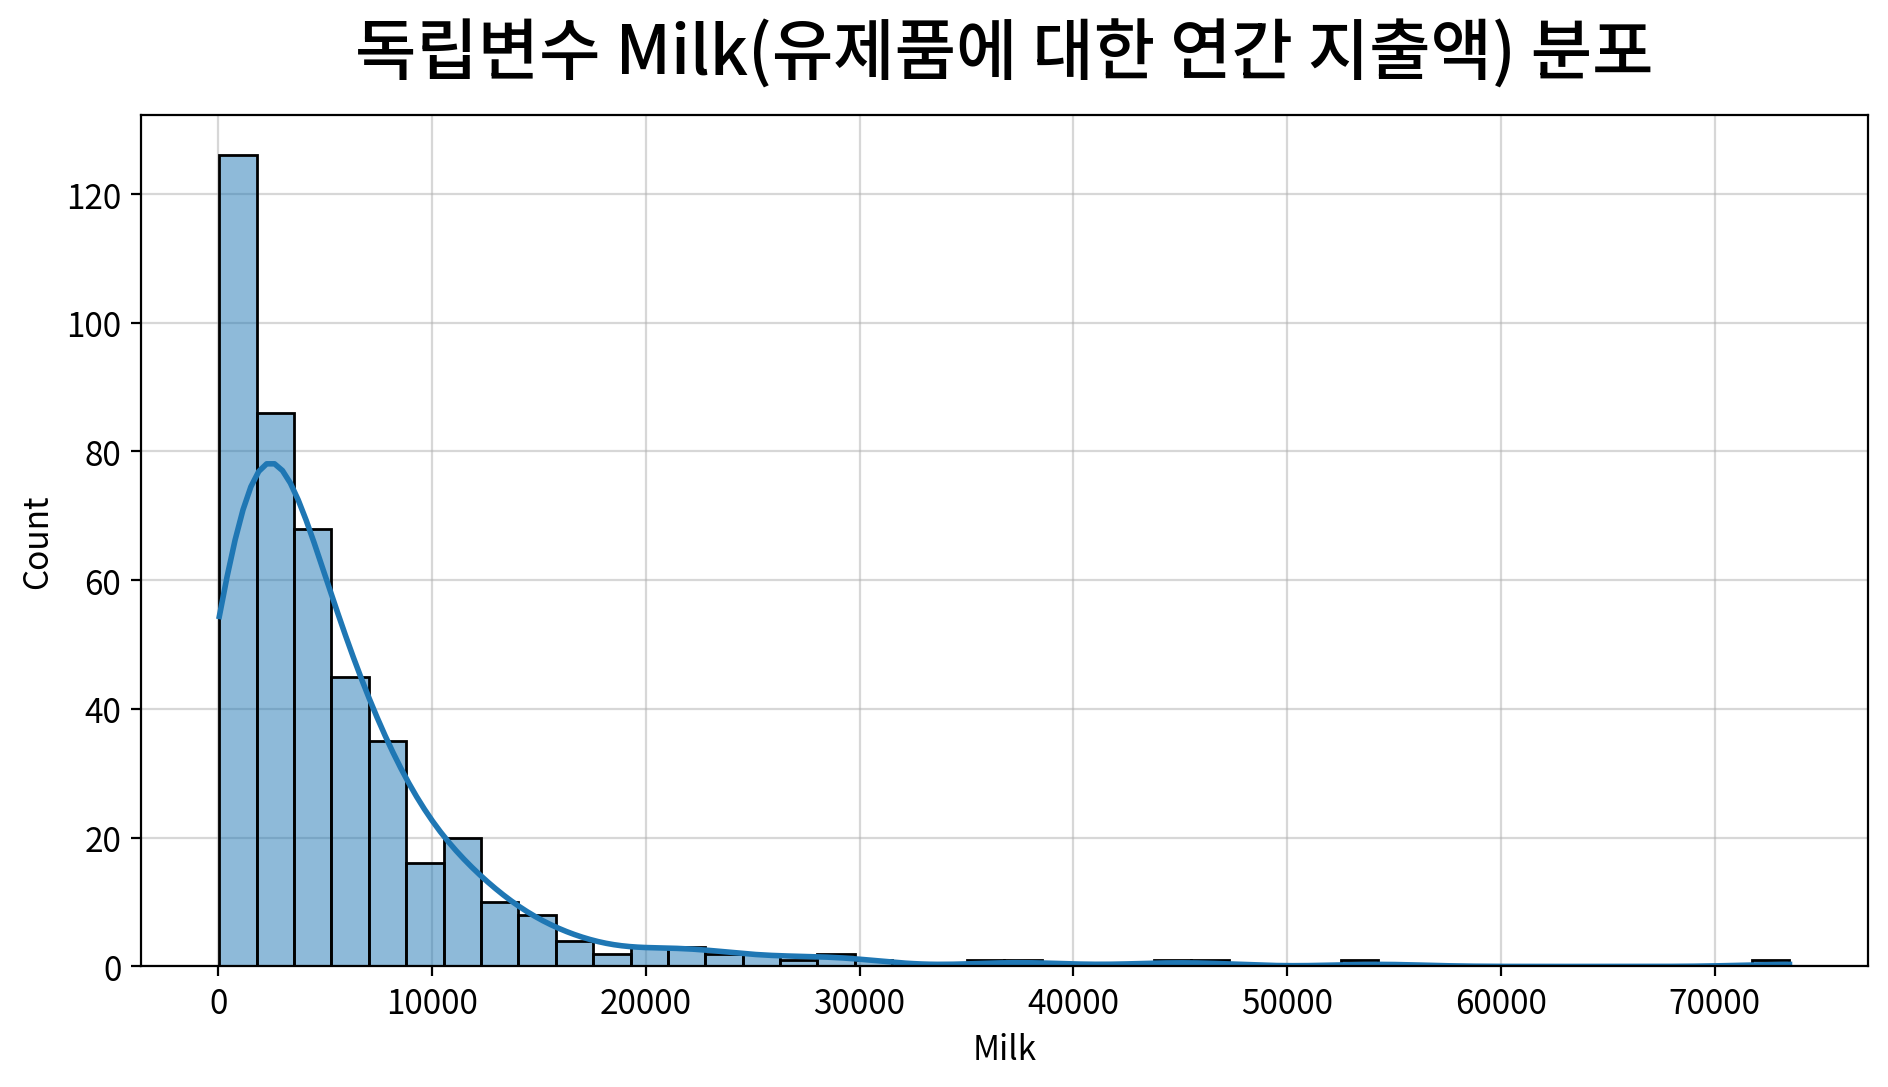

,Milk
count,440.0
mean,5796.265909
std,7380.377175
min,55.0
25%,1533.0
50%,3627.0
75%,7190.25
max,73498.0
rel_diff,0.598088
rdiff_flag,large_diff


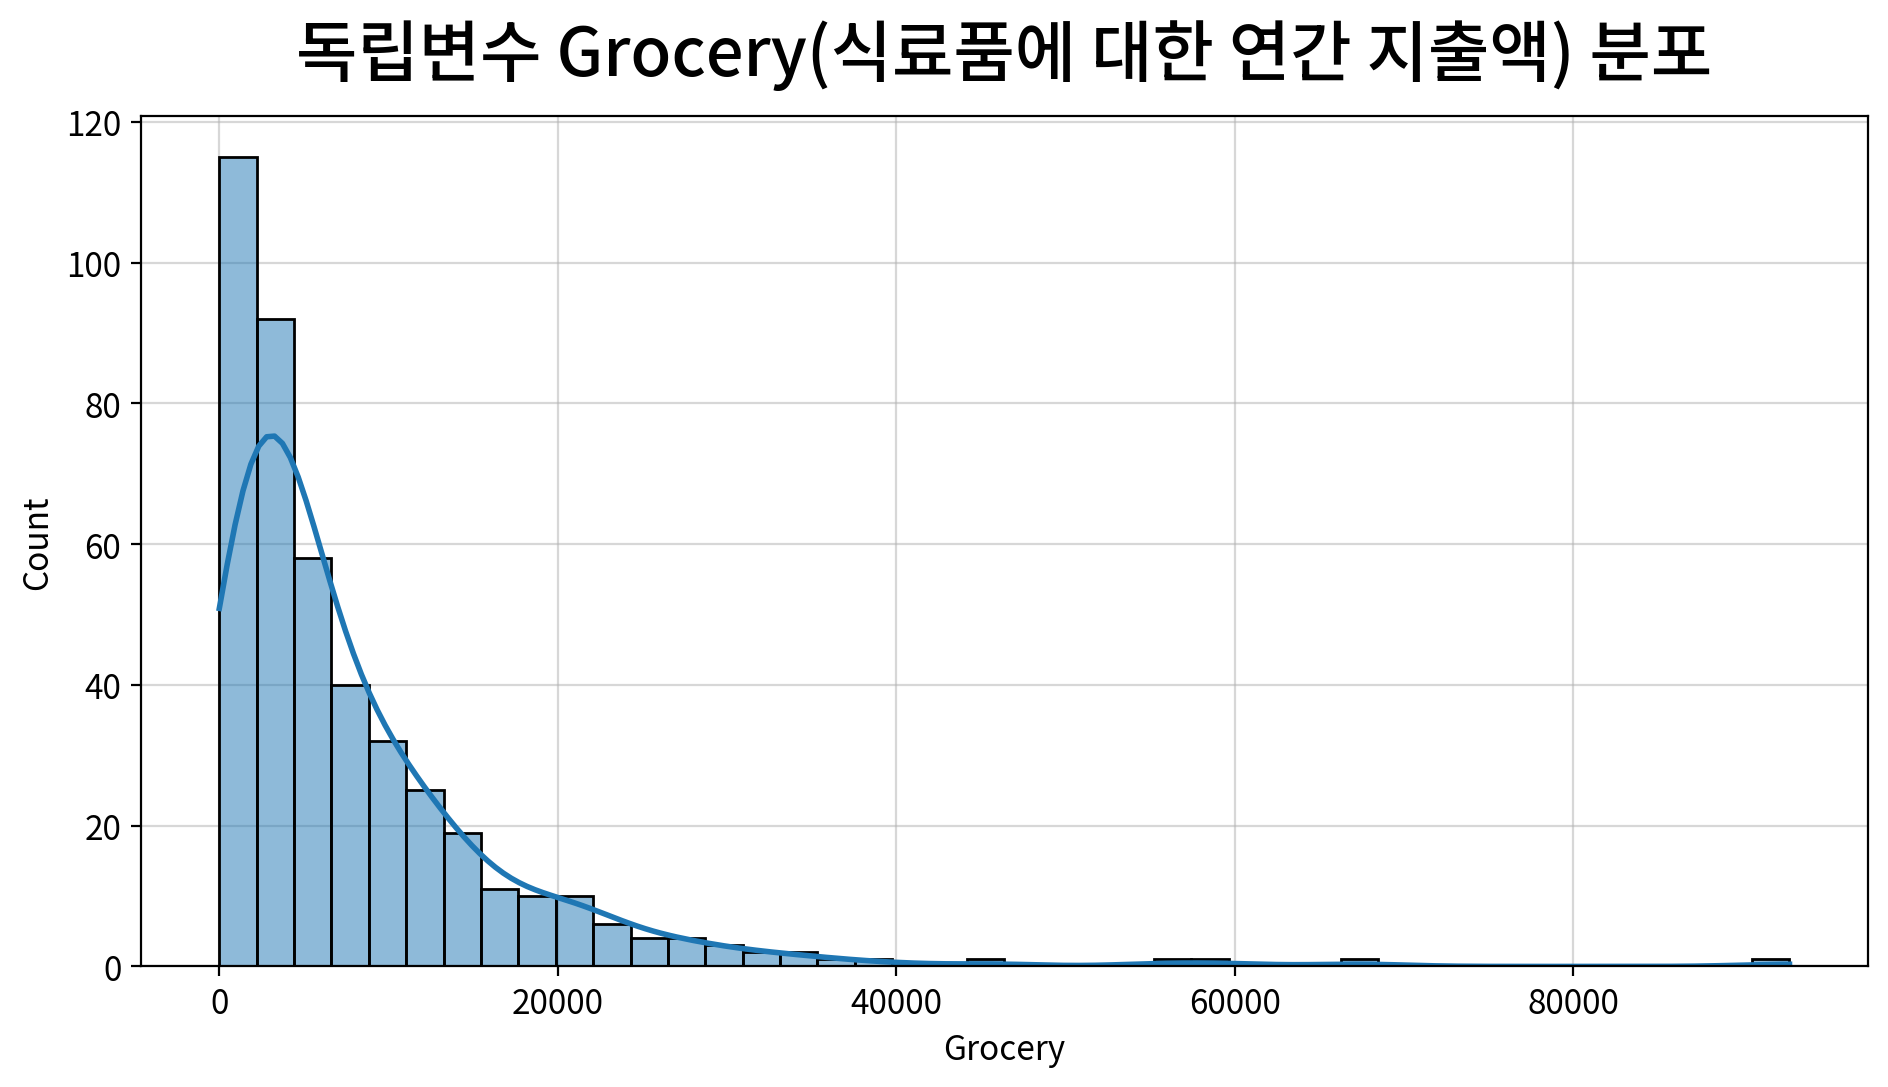

,Grocery
count,440.0
mean,7951.277273
std,9503.162829
min,3.0
25%,2153.0
50%,4755.5
75%,10655.75
max,92780.0
rel_diff,0.672017
rdiff_flag,large_diff


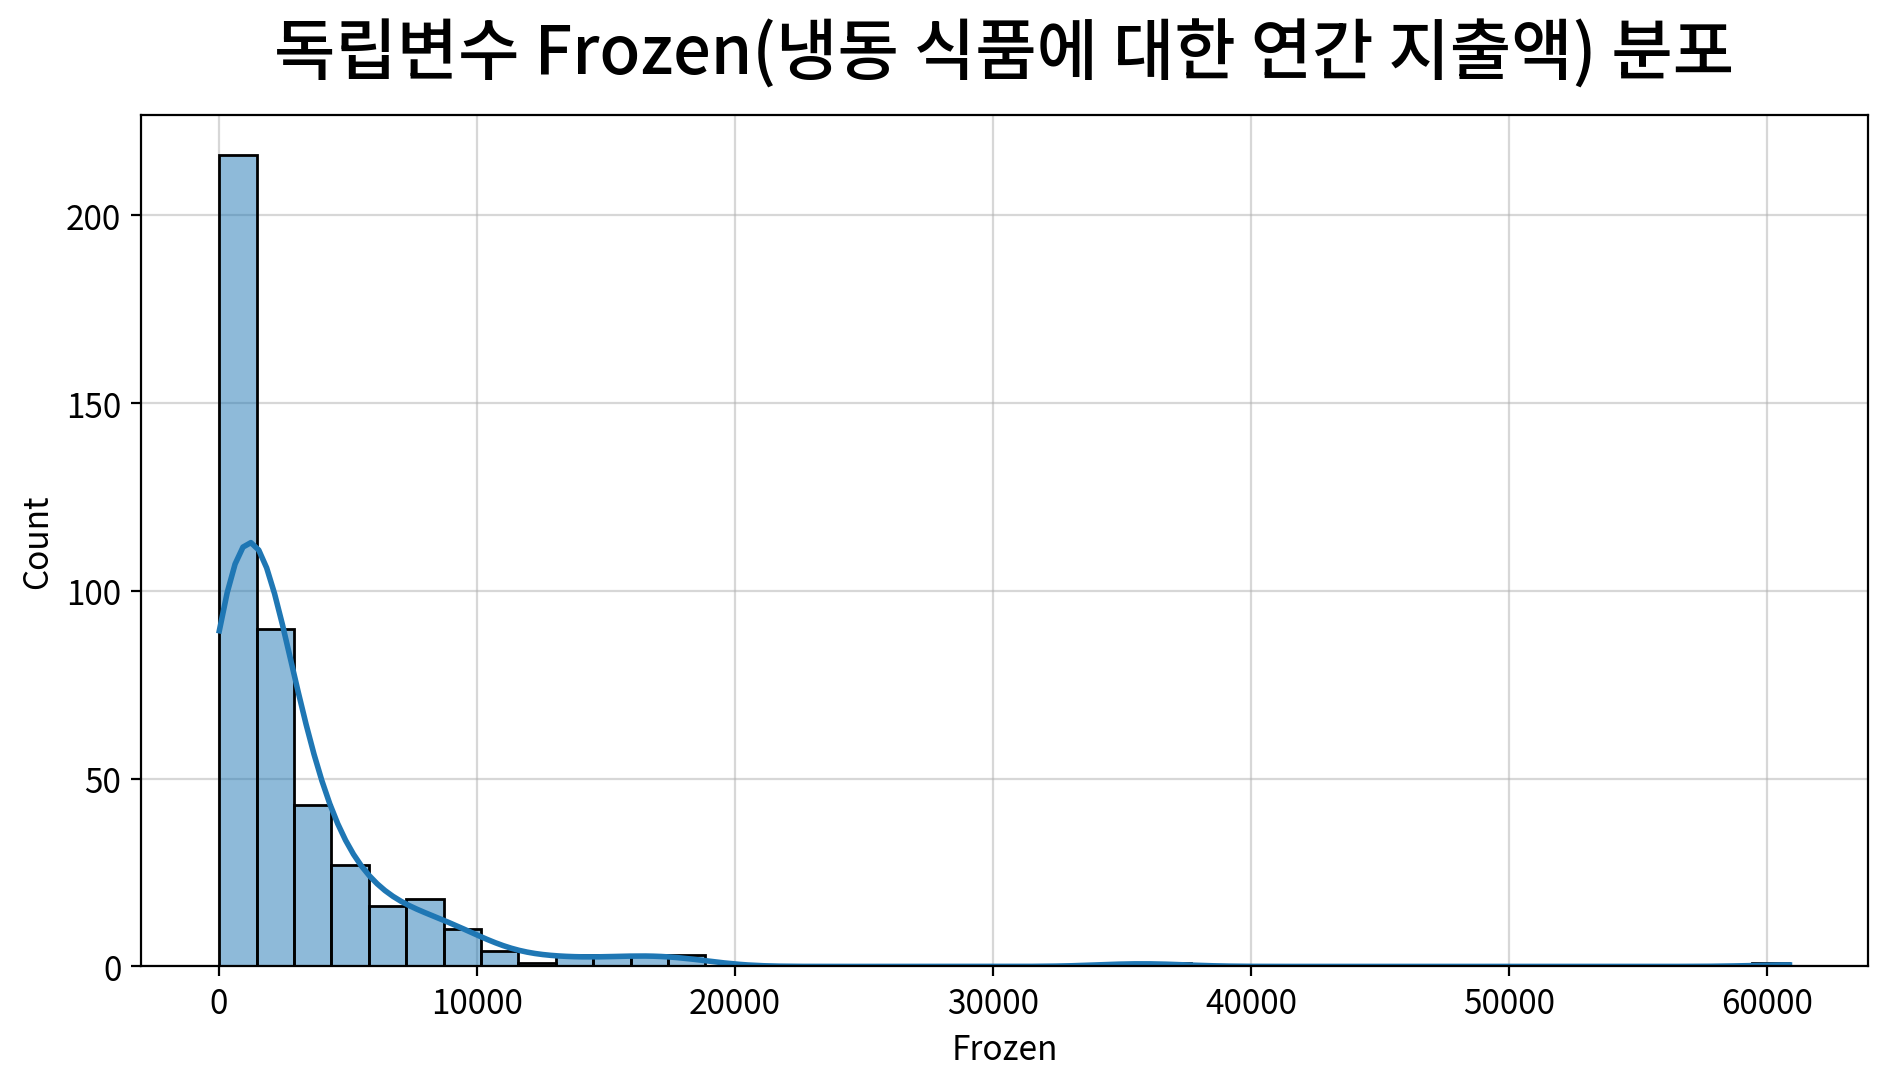

,Frozen
count,440.0
mean,3071.931818
std,4854.673333
min,25.0
25%,742.25
50%,1526.0
75%,3554.25
max,60869.0
rel_diff,1.013061
rdiff_flag,large_diff


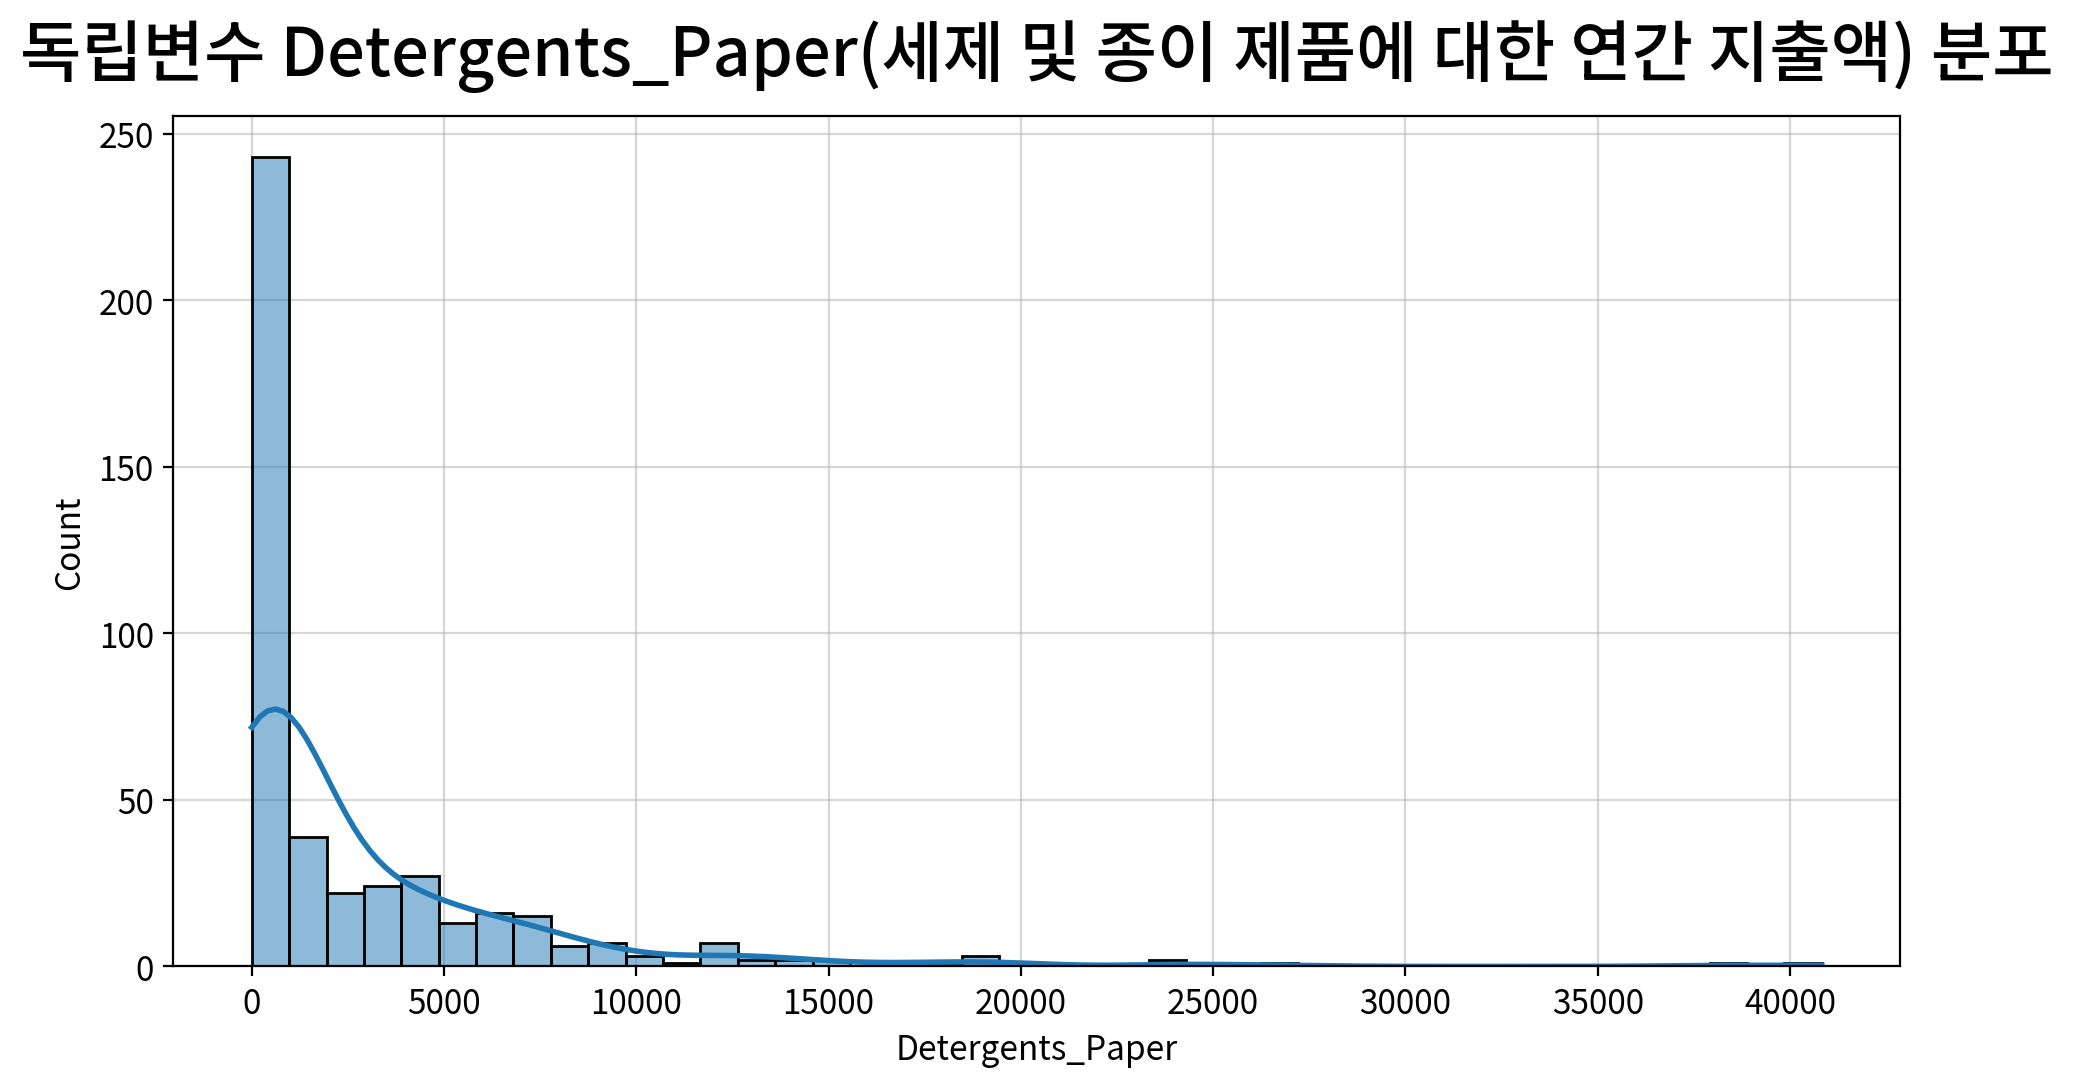

,Detergents_Paper
count,440.0
mean,2881.493182
std,4767.854448
min,3.0
25%,256.75
50%,816.5
75%,3922.0
max,40827.0
rel_diff,2.529079
rdiff_flag,large_diff


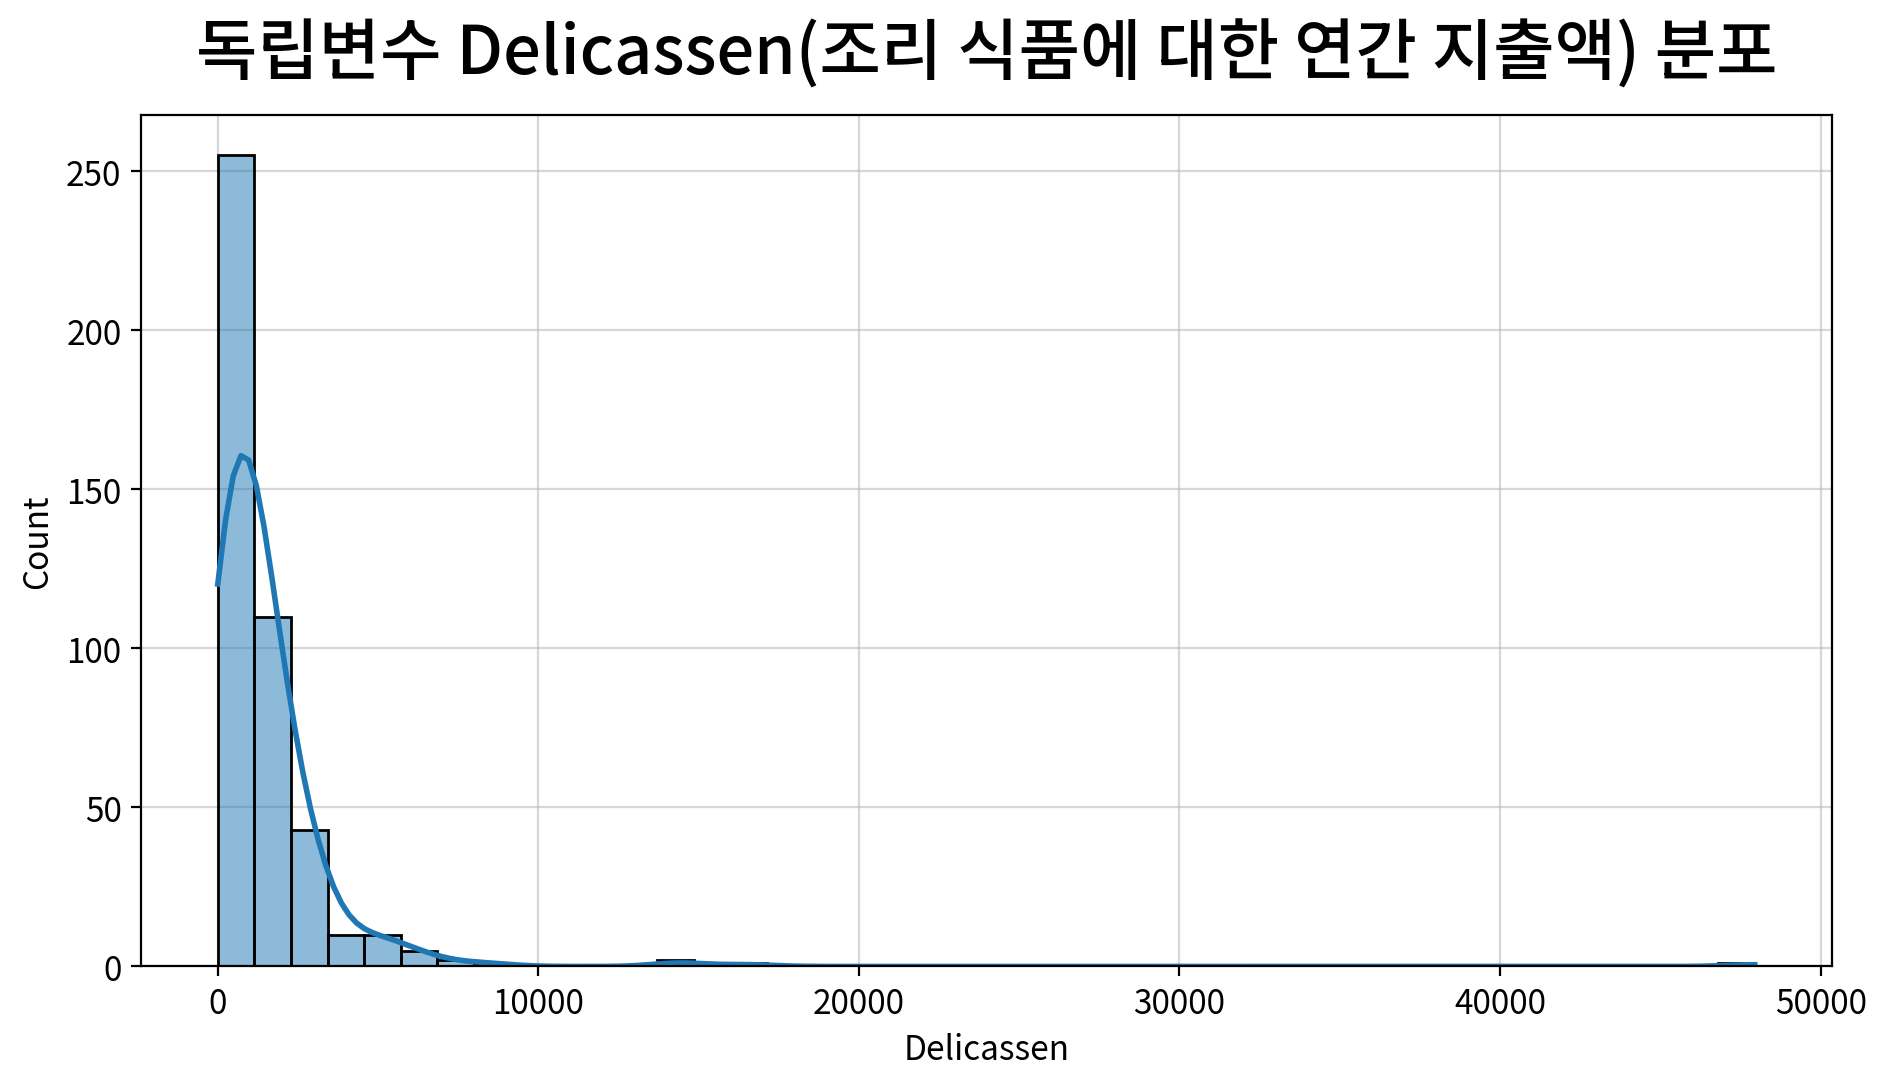

,Delicassen
count,440.0
mean,1524.870455
std,2820.105937
min,3.0
25%,408.25
50%,965.5
75%,1820.25
max,47943.0
rel_diff,0.579358
rdiff_flag,large_diff


In [16]:
for i in num_cols:
    my_plot.histplot(data=df, x=i, kde=True, width=960, height=560,
                     title = f'독립변수 {i}({column_means[i]}) 분포')
    display(num_desc[num_desc.index == i].T)

#### 2-3 범주형 독립변수에 대한 단변량 분석

In [17]:
my_plot.countplot(data=df, x=df['Region'], hue=df['Region'], palette='Set2',
                title = f'독립변수 {'Region'}({column_means['Region']})분포')

display(cat_desc[['Region']].T)

# 빈도표 생성
freq = df['Region'].value_counts().rename('빈도').to_frame()
freq['비율'] = df['Region'].value_counts(normalize=True)
display(freq)   

KeyError: 'Region'

In [ ]:
# 추후에 파이차트 그릴 예정으로, 비어놓음! 카운트 플롯 의미없음!


### 3) 이변량 분석

### 4) 다변량 분석

**3)** 추론통계 점검 (단변, 이변, 다변)

**4)** 로그변환 및 표준화(스케일링)

**5)** 로그변환 및 표준화 통계점검

## #3. 군집화

**0)** PCA(차원축소)

**1)** KMeans로 군집화

**2)** 엘보우 포인트 및 실루엣 점수로 군집수 판단

**3)** 군집별 소비성향 파악 및 요약(시각화까지)

## #4. 오분류 분석